In [1]:
import numpy as np
from scipy.optimize import approx_fprime
import matplotlib.pyplot as plt

X = np.array([[1.0, 3.0],
              [4.0, 10.0]])
y = np.array([5.0, 6.0])

m = np.array([-1.0, 2.0])
b = np.array([1.0, 1.0])

alpha = 0.01
n = X.shape[0]
n_iterations = 4

In [4]:
def predict(X, m, b):
    Xm = X @ m
    y_hat = Xm + b
    return y_hat

def cost_function(params, X, y):

    m_ = params[0:2]
    b_ = params[2:4]
    y_hat = predict(X, m_, b_)
    error = y_hat - y
    J = np.sum(error ** 2) / n
    return J

In [ ]:
def analytical_gradient(X, m, b, y):
    Xm = X @ m
    y_hat = Xm + b
    error = y_hat - y

    X_T = X.T
    XT_error = X_T @ error

    grad_m = (2.0 / n) * XT_error
    grad_b = (2.0 / n) * error

    return y_hat, error, grad_m, grad_b

In [ ]:
params0 = np.concatenate([m, b])
epsilon = np.sqrt(np.finfo(float).eps)
numerical_grad = approx_fprime(params0, cost_function, epsilon, X, y)

y_hat0, error0, grad_m0, grad_b0 = analytical_gradient(X, m, b, y)
analytical_grad_flat = np.concatenate([grad_m0, grad_b0])

print("GRADIENT CHECK AT INITIAL m, b")
print(f"Analytical gradient [dm1, dm2, db1, db2] = {analytical_grad_flat}")
print(f"SciPy numerical     [dm1, dm2, db1, db2] = {numerical_grad}")
print(f"Max absolute difference: {np.max(np.abs(analytical_grad_flat - numerical_grad)):.8f}")

GRADIENT CHECK AT INITIAL m, b
Analytical gradient [dm1, dm2, db1, db2] = [ 45. 113.   1.  11.]
SciPy numerical     [dm1, dm2, db1, db2] = [ 45.         113.00000095   1.          11.        ]
Max absolute difference: 0.00000095


In [5]:
history = {
    "iteration": [0],
    "m1": [m[0]], "m2": [m[1]],
    "b1": [b[0]], "b2": [b[1]],
    "cost": [np.sum((predict(X, m, b) - y) ** 2) / n],
}

print("MANUAL GRADIENT DESCENT FOR 4 ITERATIONS")

for i in range(1, n_iterations + 1):
    print(f"\n Iteration {i} ")

    Xm = X @ m
    print(f"X @ m            = {Xm}")
    y_hat = Xm + b
    print(f"y_hat = Xm + b   = {y_hat}")

    error = y_hat - y
    print(f"error = y_hat-y  = {error}")

    cost = np.sum(error ** 2) / n
    print(f"J (MSE)          = {cost:.6f}")

    X_T = X.T
    XT_error = X_T @ error
    grad_m = (2.0 / n) * XT_error
    print(f"X^T @ error      = {XT_error}")
    print(f"dJ/dm            = {grad_m}")

    grad_b = (2.0 / n) * error
    print(f"dJ/db            = {grad_b}")

    m = m - alpha * grad_m
    b = b - alpha * grad_b
    print(f"updated m        = {m}")
    print(f"updated b        = {b}")

    history["iteration"].append(i)
    history["m1"].append(m[0])
    history["m2"].append(m[1])
    history["b1"].append(b[0])
    history["b2"].append(b[1])
    new_cost = np.sum((predict(X, m, b) - y) ** 2) / n
    history["cost"].append(new_cost)

MANUAL GRADIENT DESCENT FOR 4 ITERATIONS

 Iteration 1 
X @ m            = [ 5. 16.]
y_hat = Xm + b   = [ 6. 17.]
error = y_hat-y  = [ 1. 11.]
J (MSE)          = 61.000000
X^T @ error      = [ 45. 113.]
dJ/dm            = [ 45. 113.]
dJ/db            = [ 1. 11.]
updated m        = [-1.45  0.87]
updated b        = [0.99 0.89]

 Iteration 2 
X @ m            = [1.16 2.9 ]
y_hat = Xm + b   = [2.15 3.79]
error = y_hat-y  = [-2.85 -2.21]
J (MSE)          = 6.503300
X^T @ error      = [-11.69 -30.65]
dJ/dm            = [-11.69 -30.65]
dJ/db            = [-2.85 -2.21]
updated m        = [-1.3331  1.1765]
updated b        = [1.0185 0.9121]

 Iteration 3 
X @ m            = [2.1964 6.4326]
y_hat = Xm + b   = [3.2149 7.3447]
error = y_hat-y  = [-1.7851  1.3447]
J (MSE)          = 2.497400
X^T @ error      = [3.5937 8.0917]
dJ/dm            = [3.5937 8.0917]
dJ/db            = [-1.7851  1.3447]
updated m        = [-1.369037  1.095583]
updated b        = [1.036351 0.898653]

 Iteration 4 
X @ m   

In [6]:
final_predictions = predict(X, m, b)
print("FINAL RESULTS AFTER 4 UPDATES")
print(f"Final m = {m}")
print(f"Final b = {b}")
print(f"Final predictions y_hat = {final_predictions}")
print(f"Actual targets       y = {y}")
print(f"Final cost J = {history['cost'][-1]:.6f}")

FINAL RESULTS AFTER 4 UPDATES
Final m = [-1.36371103  1.11912761]
Final b = [1.05681037 0.89486965]
Final predictions y_hat = [3.05048217 6.63130163]
Actual targets       y = [5. 6.]
Final cost J = 2.099581


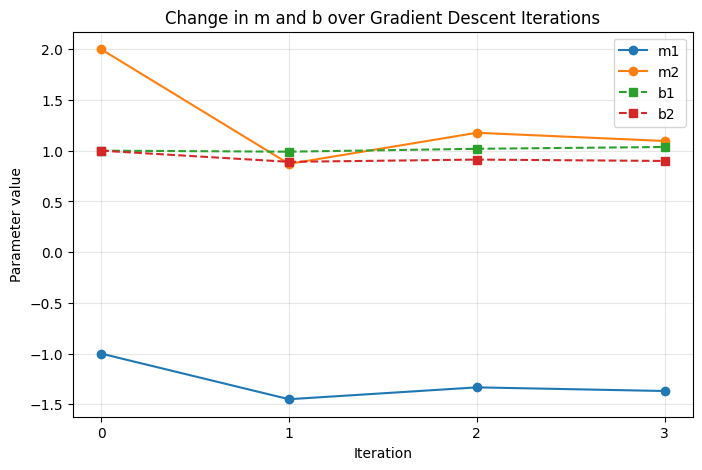

In [ ]:
fig1, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(history["iteration"], history["m1"], marker="o", label="m1")
ax1.plot(history["iteration"], history["m2"], marker="o", label="m2")
ax1.plot(history["iteration"], history["b1"], marker="s", linestyle="--", label="b1")
ax1.plot(history["iteration"], history["b2"], marker="s", linestyle="--", label="b2")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Parameter value")
ax1.set_title("Change in m and b over Gradient Descent Iterations")
ax1.set_xticks(history["iteration"])
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.show()

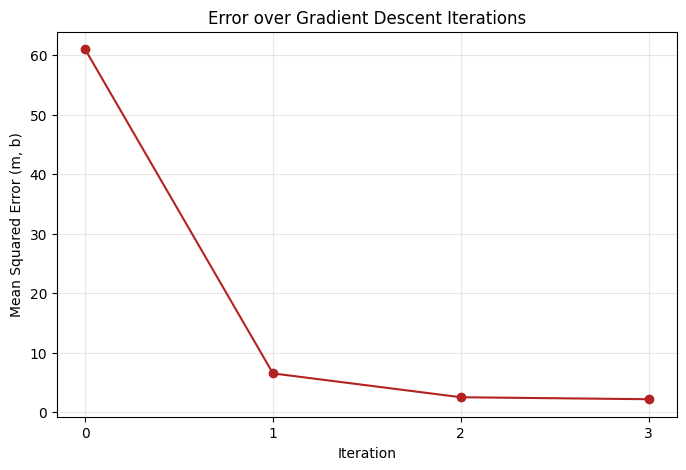

In [ ]:
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.plot(history["iteration"], history["cost"], marker="o", color="firebrick")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Mean Squared Error (m, b)")
ax2.set_title("Error over Gradient Descent Iterations")
ax2.set_xticks(history["iteration"])
ax2.grid(True, alpha=0.3)
plt.show()

#Trend observed in the values of m and b. Are they moving in a direction that reduces the error?
From the initial to the 3rd iteration, the value of Mean Squared error reduced from 61.0 to 6.50 then to 2.50 and to 2.16. Therefore, yes, the values of m and b are moving in the direction that reduces the error.